In [174]:
zip_path = "/content/drive/MyDrive/AI and Machine Learning/Copy of Copy of devnagari digit.zip"

In [175]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [176]:
import zipfile
import os

zip_path = "/content/drive/MyDrive/AI and Machine Learning/Copy of Copy of devnagari digit.zip"
extract_path = "/content/data"

os.makedirs(extract_path, exist_ok=True)

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Unzipped successfully!")

Unzipped successfully!


In [177]:
import os
os.listdir("/content/data")

['DevanagariHandwrittenDigitDataset']

In [178]:
pip install keras tensorflow

In [179]:
import tensorflow as tf
print(tf.keras.__version__)

3.13.2


Data Preparation

In [180]:
train_dir = "/content/dataset/DevanagariHandwrittenDigitDataset/Train"
test_dir  = "/content/dataset/DevanagariHandwrittenDigitDataset/Test"

In [181]:
class_names = sorted(os.listdir(train_dir))
class_map = {name: i for i, name in enumerate(class_names)}

In [182]:
import os
import numpy as np
from PIL import Image
from tensorflow.keras.utils import to_categorical
def load_images(folder, class_map):
    images = []
    labels = []

    for class_name in class_map.keys():
        class_path = os.path.join(folder, class_name)
        label = class_map[class_name]

        for filename in os.listdir(class_path):
            img_path = os.path.join(class_path, filename)

            img = Image.open(img_path).convert("L")
            img = img.resize((28, 28))
            img = np.array(img) / 255.0

            images.append(img)
            labels.append(label)

    return np.array(images), np.array(labels)

# Load dataset
x_train, y_train = load_images(train_dir, class_map)
x_test, y_test = load_images(test_dir, class_map)

# Reshape
x_train = x_train.reshape(-1, 28, 28, 1)
x_test = x_test.reshape(-1, 28, 28, 1)

# One-hot encoding
y_train = to_categorical(y_train, 10)
y_test = to_categorical(y_test, 10)

print("Train:", x_train.shape, y_train.shape)
print("Test:", x_test.shape, y_test.shape)

Train: (17000, 28, 28, 1) (17000, 10)
Test: (3000, 28, 28, 1) (3000, 10)


In [183]:
x_train, y_train = load_images(train_dir, class_map)
x_test, y_test = load_images(test_dir, class_map)

In [184]:
print(np.unique(y_train))

[0 1 2 3 4 5 6 7 8 9]


In [185]:
from tensorflow.keras.utils import to_categorical

y_train = to_categorical(y_train, 10)
y_test = to_categorical(y_test, 10)

In [186]:
print(y_train.shape)

(17000, 10)


Build FCN Model

In [187]:
from tensorflow import keras

model = keras.Sequential([
    keras.layers.Input(shape=(28, 28, 1)),

    keras.layers.Flatten(),

    keras.layers.Dense(64, activation="sigmoid"),
    keras.layers.Dense(128, activation="sigmoid"),
    keras.layers.Dense(256, activation="sigmoid"),

    keras.layers.Dense(10, activation="softmax")
])
model.summary()

Model: "sequential_12"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_11 (Flatten)            │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_49 (Dense)                │ (None, 64)             │        50,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_50 (Dense)                │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_51 (Dense)                │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_52 (Dense)                │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 94,154 (367.79 KB)

 Trainable params: 94,154 (367.79 KB)

 Non-trainable params: 0 (0.00 B)

Compile Model

In [188]:
model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

Train Model

In [189]:
history = model.fit(
    x_train,
    y_train,
    batch_size=128,
    epochs=20,
    validation_data=(x_test, y_test)
)

Epoch 1/20
133/133 ━━━━━━━━━━━━━━━━━━━━ 8s 22ms/step - accuracy: 0.4914 - loss: 1.6739 - val_accuracy: 0.7923 - val_loss: 0.7700
Epoch 2/20
133/133 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.8471 - loss: 0.5117 - val_accuracy: 0.8903 - val_loss: 0.3723
Epoch 3/20
133/133 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9133 - loss: 0.2935 - val_accuracy: 0.9277 - val_loss: 0.2443
Epoch 4/20
133/133 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9437 - loss: 0.1975 - val_accuracy: 0.9457 - val_loss: 0.1839
Epoch 5/20
133/133 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9580 - loss: 0.1478 - val_accuracy: 0.9533 - val_loss: 0.1546
Epoch 6/20
133/133 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9674 - loss: 0.1166 - val_accuracy: 0.9603 - val_loss: 0.1385
Epoch 7/20
133/133 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9741 - loss: 0.0943 - val_accuracy: 0.9677 - val_loss: 0.1124
Epoch 8/20
133/133 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9801 - loss: 0.0765 - val_accuracy: 0

Evaluate Model

In [190]:
test_loss, test_acc = model.evaluate(x_test, y_test)
print("Test Accuracy:", test_acc)

94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9833 - loss: 0.0679
Test Accuracy: 0.9833333492279053


Save And Load Model

In [191]:
# Save model
model.save("devnagari_fcn_model.h5")

# Load model
loaded_model = keras.models.load_model("devnagari_fcn_model.h5")

# Re-evaluate
loss, acc = loaded_model.evaluate(x_test, y_test)
print("Loaded Model Accuracy:", acc)

94/94 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9833 - loss: 0.0679
Loaded Model Accuracy: 0.9833333492279053


Prediction

In [192]:
import numpy as np

predictions = model.predict(x_test)
predicted_labels = np.argmax(predictions, axis=1)

print("Predicted:", predicted_labels[0])
print("Actual:", np.argmax(y_test[0]))

94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
Predicted: 0
Actual: 0


Visualizations

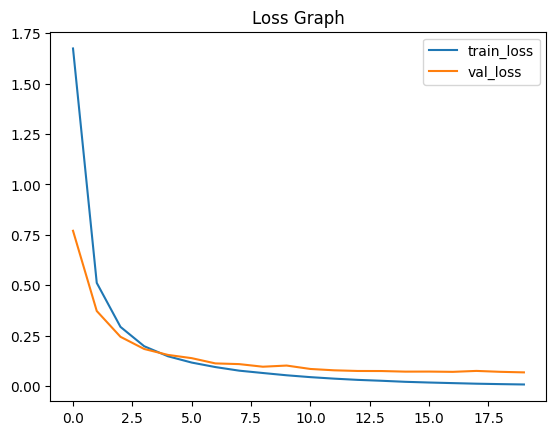

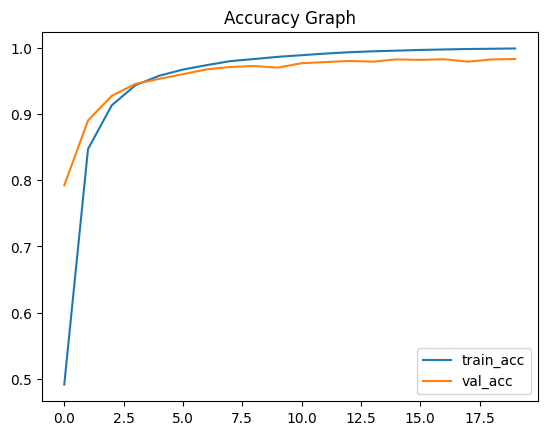

In [193]:
import matplotlib.pyplot as plt

# Loss graph
plt.plot(history.history['loss'], label='train_loss')
plt.plot(history.history['val_loss'], label='val_loss')
plt.legend()
plt.title("Loss Graph")
plt.show()

# Accuracy graph
plt.plot(history.history['accuracy'], label='train_acc')
plt.plot(history.history['val_accuracy'], label='val_acc')
plt.legend()
plt.title("Accuracy Graph")
plt.show()